### Importación de datos



In [39]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [ ]:
tienda4.shape

(2358, 12)

In [2]:
type(tienda1)

pandas.core.frame.DataFrame

#1. Análisis de facturación



In [3]:
#Ingreso total por cada tienda
totalprecio_tienda1 = tienda1["Precio"].sum()
totalprecio_tienda2 = tienda2["Precio"].sum()
totalprecio_tienda3 = tienda3["Precio"].sum()
totalprecio_tienda4 = tienda4["Precio"].sum()

print("La suma total de la tienda1 es $ {:,}".format(totalprecio_tienda1))
print("La suma total de la tienda2 es $ {:,}".format(totalprecio_tienda2))
print("La suma total de la tienda3 es $ {:,}".format(totalprecio_tienda3))
print("La suma total de la tienda4 es $ {:,}".format(totalprecio_tienda4))

La suma total de la tienda1 es $ 1,150,880,400.0
La suma total de la tienda2 es $ 1,116,343,500.0
La suma total de la tienda3 es $ 1,098,019,600.0
La suma total de la tienda4 es $ 1,038,375,700.0


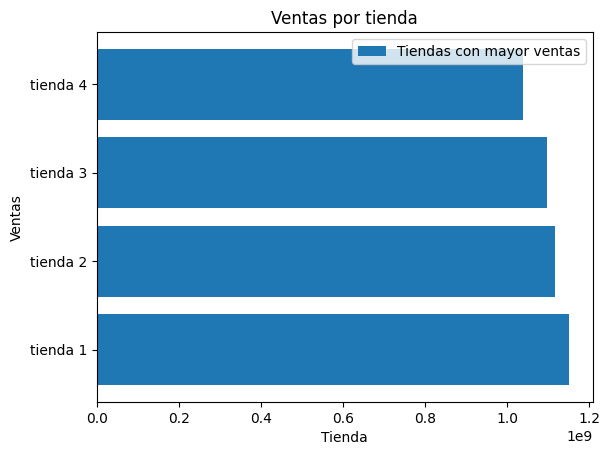

In [3]:
#analizando las sumas total de ventas la que mas ha vendido es la tienda 1
plt.barh(['tienda 1','tienda 2','tienda 3','tienda 4'], [totalprecio_tienda1, totalprecio_tienda2, totalprecio_tienda3, totalprecio_tienda4], align="center", label="Tiendas con mayor ventas")
plt.title('Ventas por tienda')
plt.xlabel('Tienda')
plt.ylabel('Ventas')
plt.legend()
plt.show()

In [5]:
tienda1['Fecha de Compra'] = pd.to_datetime(tienda1['Fecha de Compra'],format='%d/%m/%Y')
tienda1['Mes_año'] = tienda1['Fecha de Compra'].dt.to_period('M')

tienda2['Fecha de Compra'] = pd.to_datetime(tienda2['Fecha de Compra'],format='%d/%m/%Y')
tienda2['Mes_año'] = tienda2['Fecha de Compra'].dt.to_period('M')

tienda3['Fecha de Compra'] = pd.to_datetime(tienda3['Fecha de Compra'],format='%d/%m/%Y')
tienda3['Mes_año'] = tienda3['Fecha de Compra'].dt.to_period('M')

tienda4['Fecha de Compra'] = pd.to_datetime(tienda4['Fecha de Compra'],format='%d/%m/%Y')
tienda4['Mes_año'] = tienda4['Fecha de Compra'].dt.to_period('M')

In [14]:
#ventas en el tiempo por cada tienda
venta_tiempo_tienda1 = tienda1.groupby('Mes_año')['Precio'].sum().reset_index(name='Ventas').sort_values(by='Mes_año', ascending=False)
venta_tiempo_tienda2 = tienda2.groupby('Mes_año')['Precio'].sum().reset_index(name='Ventas').sort_values(by='Mes_año', ascending=False)
venta_tiempo_tienda3 = tienda3.groupby('Mes_año')['Precio'].sum().reset_index(name='Ventas').sort_values(by='Mes_año', ascending=False)
venta_tiempo_tienda4 = tienda4.groupby('Mes_año')['Precio'].sum().reset_index(name='Ventas').sort_values(by='Mes_año', ascending=False)

venta_tiempo_tienda1

,Mes_año,Ventas
38,2023-03,37103000.0
37,2023-02,37227700.0
36,2023-01,28930100.0
35,2022-12,34202300.0
34,2022-11,23656300.0
33,2022-10,14682000.0
32,2022-09,37111000.0
31,2022-08,27796000.0
30,2022-07,27251400.0
29,2022-06,24984500.0


In [17]:
type(venta_tiempo_tienda2)

pandas.core.frame.DataFrame

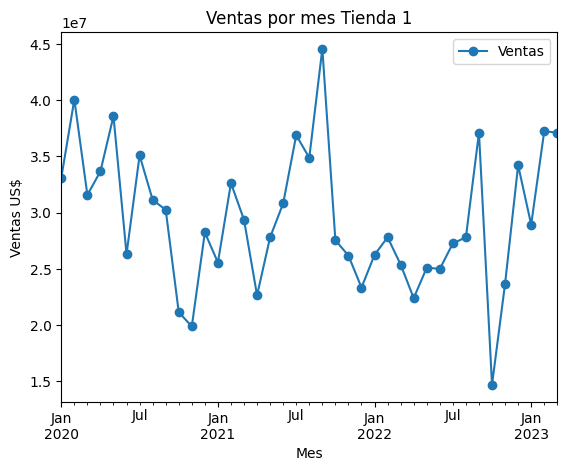

In [23]:
venta_tiempo_tienda1.plot(kind='line', x='Mes_año', y='Ventas', marker='o')
plt.title('Ventas por mes Tienda 1')
plt.xlabel('Mes')
plt.ylabel('Ventas US$')
plt.show()

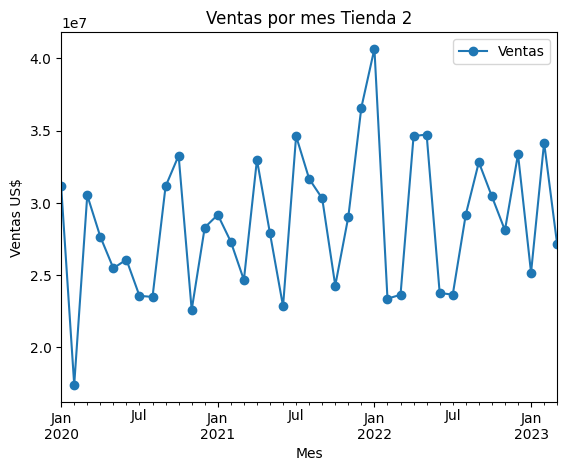

In [24]:
venta_tiempo_tienda2.plot(kind='line', x='Mes_año', y='Ventas', marker='o')
plt.title('Ventas por mes Tienda 2')
plt.xlabel('Mes')
plt.ylabel('Ventas US$')
plt.show()

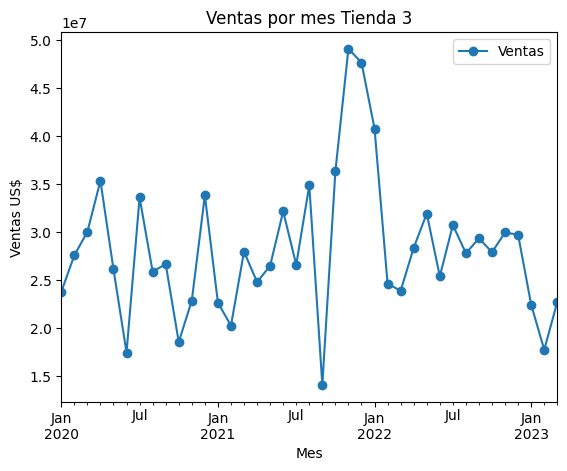

In [25]:
venta_tiempo_tienda3.plot(kind='line', x='Mes_año', y='Ventas', marker='o')
plt.title('Ventas por mes Tienda 3')
plt.xlabel('Mes')
plt.ylabel('Ventas US$')
plt.show()

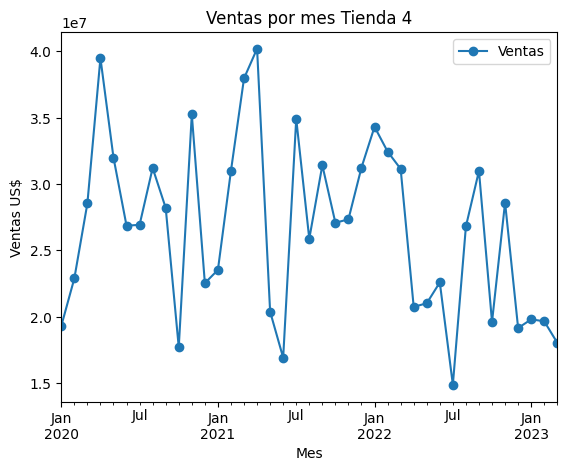

In [26]:
venta_tiempo_tienda4.plot(kind='line', x='Mes_año', y='Ventas', marker='o')
plt.title('Ventas por mes Tienda 4')
plt.xlabel('Mes')
plt.ylabel('Ventas US$')
plt.show()

# 2. Ventas por categoría

#### En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [ ]:
#Venta por CATEGORIAS - La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo
tienda1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [40]:
#ahora mostramos la informacion necesaria para comparar por categora del producto
venta_categ_tienda1 = tienda1.groupby('Categoría del Producto')['Precio'].count().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
venta_categ_tienda2 = tienda2.groupby('Categoría del Producto')['Precio'].count().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
venta_categ_tienda3 = tienda3.groupby('Categoría del Producto')['Precio'].count().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
venta_categ_tienda4 = tienda4.groupby('Categoría del Producto')['Precio'].count().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)

In [20]:
venta_categ_tienda1
# La Categoria mas vendida de la tienda 1 es:

,Categoría del Producto,Ventas
7,Muebles,465
3,Electrónicos,448
5,Juguetes,324
2,Electrodomésticos,312
1,Deportes y diversión,284
4,Instrumentos musicales,182
6,Libros,173
0,Artículos para el hogar,171


In [21]:
venta_categ_tienda2
# La Categoria mas vendida de la tienda 2 es:

,Categoría del Producto,Ventas
7,Muebles,442
3,Electrónicos,422
5,Juguetes,313
2,Electrodomésticos,305
1,Deportes y diversión,275
4,Instrumentos musicales,224
6,Libros,197
0,Artículos para el hogar,181


In [22]:
venta_categ_tienda3
# La Categoria mas vendida de la tienda 3 es:

,Categoría del Producto,Ventas
7,Muebles,499
3,Electrónicos,451
5,Juguetes,315
2,Electrodomésticos,278
1,Deportes y diversión,277
6,Libros,185
0,Artículos para el hogar,177
4,Instrumentos musicales,177


In [23]:
venta_categ_tienda4
# La Categoria mas vendida de la tienda 4 es:

,Categoría del Producto,Ventas
7,Muebles,480
3,Electrónicos,451
5,Juguetes,338
1,Deportes y diversión,277
2,Electrodomésticos,254
0,Artículos para el hogar,201
6,Libros,187
4,Instrumentos musicales,170


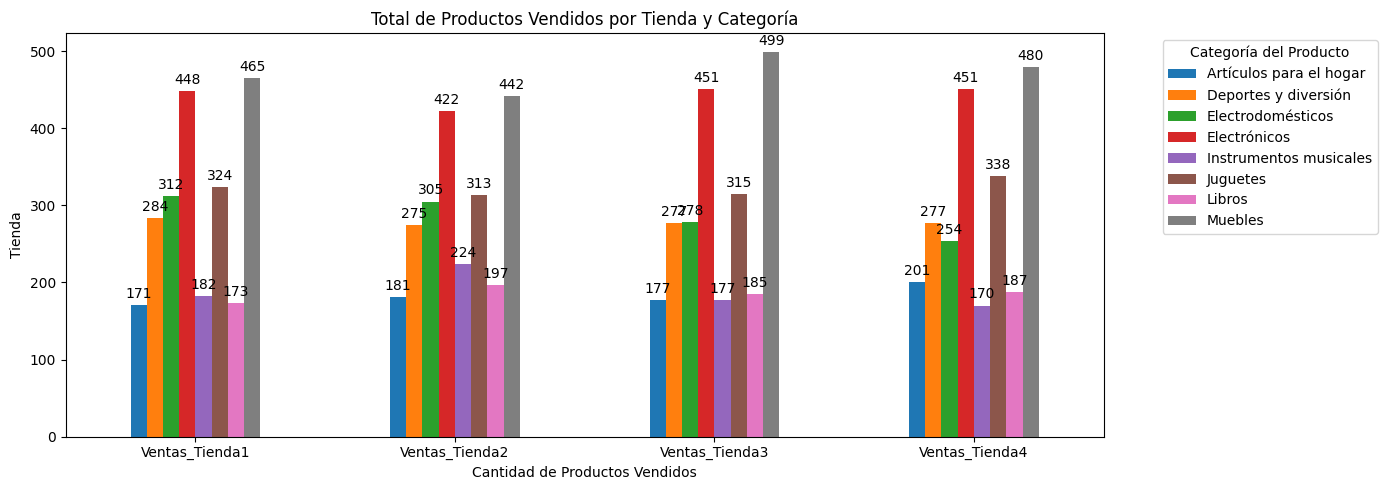

,Ventas_Tienda1,Ventas_Tienda2,Ventas_Tienda3,Ventas_Tienda4
Categoría del Producto,,,,
Muebles,465,442,499,480
Electrónicos,448,422,451,451
Juguetes,324,313,315,338
Electrodomésticos,312,305,278,254
Deportes y diversión,284,275,277,277
Instrumentos musicales,182,224,177,170
Libros,173,197,185,187
Artículos para el hogar,171,181,177,201


In [74]:
venta_categ_tienda1_r = venta_categ_tienda1.rename(columns={'Ventas': 'Tienda1'})
venta_categ_tienda2_r = venta_categ_tienda2.rename(columns={'Ventas': 'Tienda2'})
venta_categ_tienda3_r = venta_categ_tienda3.rename(columns={'Ventas': 'Tienda3'})
venta_categ_tienda4_r = venta_categ_tienda4.rename(columns={'Ventas': 'Tienda4'})

ventas_por_categoria_total = pd.merge(venta_categ_tienda1_r, venta_categ_tienda2_r, on='Categoría del Producto', how='outer')
ventas_por_categoria_total = pd.merge(ventas_por_categoria_total, venta_categ_tienda3_r, on='Categoría del Producto', how='outer')
ventas_por_categoria_total = pd.merge(ventas_por_categoria_total, venta_categ_tienda4_r, on='Categoría del Producto', how='outer')

ventas_por_categoria_total.set_index('Categoría del Producto', inplace=True)

ax = ventas_por_categoria_total.T.plot(kind='bar', figsize=(14, 5))
plt.title('Total de Productos Vendidos por Tienda y Categoría')
plt.ylabel('Tienda')
plt.xlabel('Cantidad de Productos Vendidos')
plt.xticks(rotation=0)
plt.legend(title='Categoría del Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()
ventas_por_categoria_total.sort_values(by='Ventas_Tienda1', ascending=False)


# 3. Calificación promedio de la tienda


####En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la **satisfacción del cliente** con los productos vendidos.

In [ ]:
#Calculamos el promedio de calificacion de cada tienda

In [5]:
promedio_tienda1 = tienda1["Calificación"].mean()
promedio_tienda2 = tienda2["Calificación"].mean()
promedio_tienda3 = tienda3["Calificación"].mean()
promedio_tienda4 = tienda4["Calificación"].mean()

print(f"La Calificacion promedio de tienda1 es {promedio_tienda1:.2f}")
print(f"La Calificacion promedio de tienda2 es {promedio_tienda2:.2f}")
print(f"La Calificacion promedio de tienda3 es {promedio_tienda3:.2f}")
print(f"La Calificacion promedio de tienda4 es {promedio_tienda4:.2f}")

La Calificacion promedio de tienda1 es 3.98
La Calificacion promedio de tienda2 es 4.04
La Calificacion promedio de tienda3 es 4.05
La Calificacion promedio de tienda4 es 4.00


In [ ]:
# La tienda con mejor promedio es la tienda 3


# 4. Productos más y menos vendidos

####En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [12]:
#agrupamos los prouctos y sus ventas y suma de precio ordenado
ventas1 = tienda1.groupby('Producto').agg(Cantidad_prod=('Producto','count'), Suma_precio=('Precio','sum')).reset_index().sort_values(by=['Cantidad_prod', 'Suma_precio'], ascending=[False, False])
ventas2 = tienda2.groupby('Producto').agg(Cantidad_prod=('Producto','count'), Suma_precio=('Precio','sum')).reset_index().sort_values(by=['Cantidad_prod', 'Suma_precio'], ascending=[False, False])
ventas3 = tienda3.groupby('Producto').agg(Cantidad_prod=('Producto','count'), Suma_precio=('Precio','sum')).reset_index().sort_values(by=['Cantidad_prod', 'Suma_precio'], ascending=[False, False])
ventas4 = tienda4.groupby('Producto').agg(Cantidad_prod=('Producto','count'), Suma_precio=('Precio','sum')).reset_index().sort_values(by=['Cantidad_prod', 'Suma_precio'], ascending=[False, False])

In [22]:
venta_tienda1_mas_vendido = ventas1.iloc[0]
venta_tienda1_menos_vendido = ventas1.iloc[-1]

venta_tienda2_mas_vendido = ventas2.iloc[0]
venta_tienda2_menos_vendido = ventas2.iloc[-1]

venta_tienda3_mas_vendido = ventas3.iloc[0]
venta_tienda3_menos_vendido = ventas3.iloc[-1]

venta_tienda4_mas_vendido = ventas4.iloc[0]
venta_tienda4_menos_vendido = ventas4.iloc[-1]

In [27]:
print(f"TIENDA 1 El producto mas vendido es: {venta_tienda1_mas_vendido['Producto']} con {venta_tienda1_mas_vendido['Cantidad_prod']} unidades")
print(f"TIENDA 1 El producto menos vendido es: {venta_tienda1_menos_vendido['Producto']} con {venta_tienda1_menos_vendido['Cantidad_prod']} unidades")
print()
print(f"TIENDA 2 El producto mas vendido es: {venta_tienda2_mas_vendido['Producto']} con {venta_tienda2_mas_vendido['Cantidad_prod']} unidades")
print(f"TIENDA 2 El producto menos vendido es: {venta_tienda2_menos_vendido['Producto']} con {venta_tienda2_menos_vendido['Cantidad_prod']} unidades")
print()
print(f"TIENDA 3 El producto mas vendido es: {venta_tienda3_mas_vendido['Producto']} con {venta_tienda3_mas_vendido['Cantidad_prod']} unidades")
print(f"TIENDA 3 El producto menos vendido es: {venta_tienda3_menos_vendido['Producto']} con {venta_tienda3_menos_vendido['Cantidad_prod']} unidades")
print()
print(f"TIENDA 4 El producto mas vendido es: {venta_tienda4_mas_vendido['Producto']} con {venta_tienda4_mas_vendido['Cantidad_prod']} unidades")
print(f"TIENDA 4 El producto menos vendido es: {venta_tienda4_menos_vendido['Producto']} con {venta_tienda4_menos_vendido['Cantidad_prod']} unidades")

TIENDA 1 El producto mas vendido es: TV LED UHD 4K con 60 unidades
TIENDA 1 El producto menos vendido es: Auriculares con micrófono con 33 unidades

TIENDA 2 El producto mas vendido es: Iniciando en programación con 65 unidades
TIENDA 2 El producto menos vendido es: Juego de mesa con 32 unidades

TIENDA 3 El producto mas vendido es: Kit de bancas con 57 unidades
TIENDA 3 El producto menos vendido es: Bloques de construcción con 35 unidades

TIENDA 4 El producto mas vendido es: Cama box con 62 unidades
TIENDA 4 El producto menos vendido es: Guitarra eléctrica con 33 unidades


# 5. Envío promedio por tienda

#####En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [3]:
costo_envio_tienda1 = tienda1["Costo de envío"].mean()
costo_envio_tienda2 = tienda2["Costo de envío"].mean()
costo_envio_tienda3 = tienda3["Costo de envío"].mean()
costo_envio_tienda4 = tienda4["Costo de envío"].mean()

In [4]:
print(f"El costo de envio promedio de la tienda1 es {costo_envio_tienda1:.2f}")
print()
print(f"El costo de envio promedio de la tienda2 es {costo_envio_tienda2:.2f}")
print()
print(f"El costo de envio promedio de la tienda3 es {costo_envio_tienda3:.2f}")
print()
print(f"El costo de envio promedio de la tienda4 es {costo_envio_tienda4:.2f}")

El costo de envio promedio de la tienda1 es 26018.61

El costo de envio promedio de la tienda2 es 25216.24

El costo de envio promedio de la tienda3 es 24805.68

El costo de envio promedio de la tienda4 es 23459.46


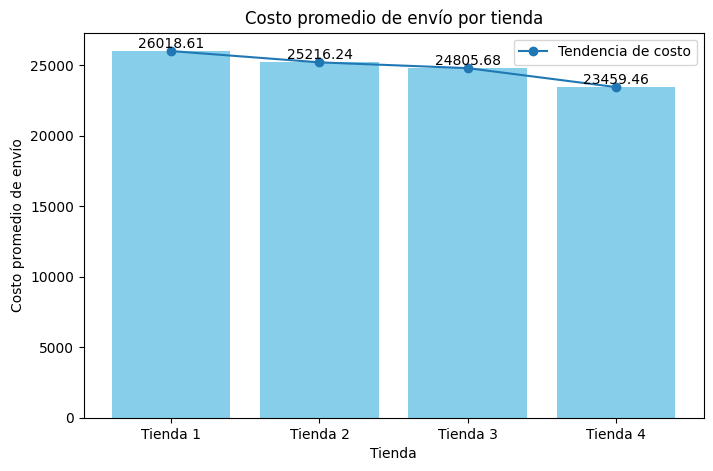

In [14]:
import numpy as np

data_costo = pd.DataFrame({'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'], 'Costo promedio de envío': [costo_envio_tienda1, costo_envio_tienda2, costo_envio_tienda3, costo_envio_tienda4]})
plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(data_costo['Tienda'])), data_costo['Costo promedio de envío'], align='center', color='skyblue')
plt.plot(np.arange(len(data_costo['Tienda'])), data_costo['Costo promedio de envío'], marker='o', linestyle='-',label ='Tendencia de costo')
for i, v in enumerate(data_costo['Costo promedio de envío']):
    plt.text(np.arange(len(data_costo['Costo promedio de envío']))[i], v, f'{v:.2f}', ha='center', va='bottom')
plt.xticks(np.arange(len(data_costo['Tienda'])), data_costo['Tienda'])
plt.xlabel('Tienda')
plt.ylabel('Costo promedio de envío')
plt.title('Costo promedio de envío por tienda')
plt.legend()
plt.show()

# ¡Extra! Análisis del desempeño geográfico

#####tendrás el desafío de explorar las coordenadas geográficas de los datos de ventas e identificar patrones relacionados con la ubicación de las compras. Al utilizar las columnas de latitud y longitud, puede generar visualizaciones para comprender cómo varían las ventas según la ubicación geográfica.

In [25]:
dispersion_tienda1 = tienda1.groupby(['lat', 'lon'])['Precio'].sum().reset_index()
dispersion_tienda2 = tienda2.groupby(['lat', 'lon'])['Precio'].sum().reset_index()
dispersion_tienda3 = tienda3.groupby(['lat', 'lon'])['Precio'].sum().reset_index()
dispersion_tienda4 = tienda4.groupby(['lat', 'lon'])['Precio'].sum().reset_index()

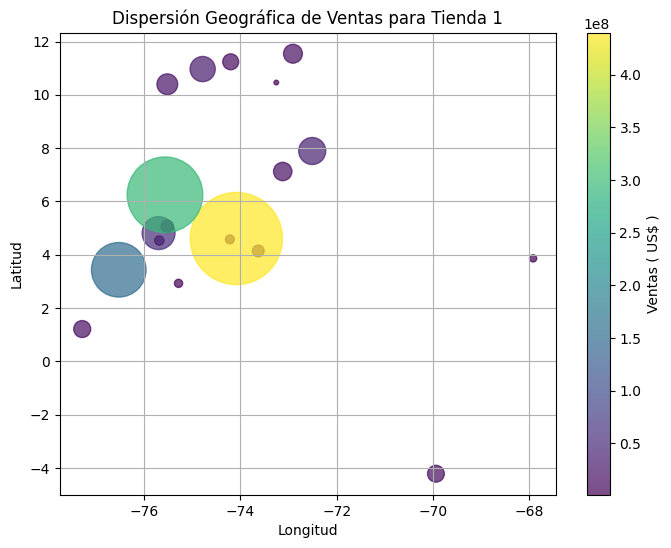

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(dispersion_tienda1['lon'], dispersion_tienda1['lat'], c=dispersion_tienda1['Precio'], cmap='viridis', s=dispersion_tienda1['Precio']/100000, alpha=0.7)
plt.colorbar(label='Ventas ( US$ )')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Dispersión Geográfica de Ventas para Tienda 1')
plt.grid(True)
plt.show()

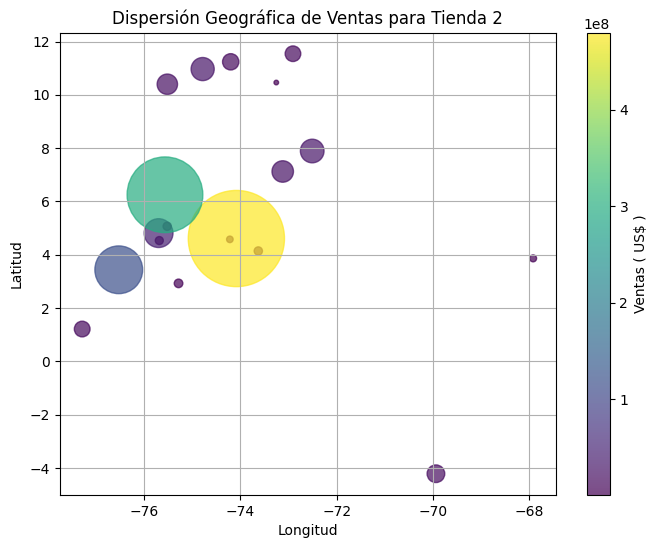

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(dispersion_tienda2['lon'], dispersion_tienda2['lat'], c=dispersion_tienda2['Precio'], cmap='viridis', s=dispersion_tienda2['Precio']/100000, alpha=0.7)
plt.colorbar(label='Ventas ( US$ )')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Dispersión Geográfica de Ventas para Tienda 2')
plt.grid(True)
plt.show()

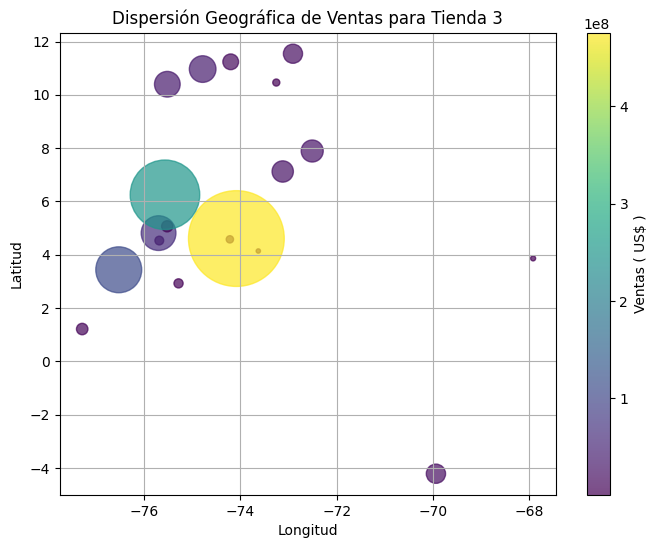

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(dispersion_tienda3['lon'], dispersion_tienda3['lat'], c=dispersion_tienda3['Precio'], cmap='viridis', s=dispersion_tienda3['Precio']/100000, alpha=0.7)
plt.colorbar(label='Ventas ( US$ )')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Dispersión Geográfica de Ventas para Tienda 3')
plt.grid(True)
plt.show()

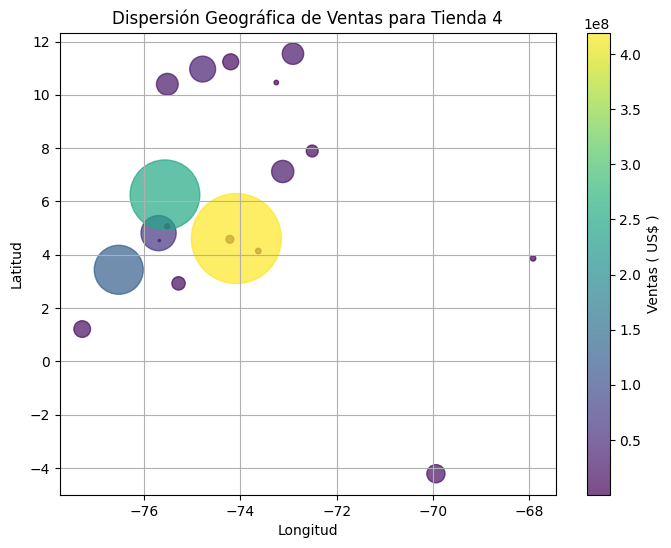

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(dispersion_tienda4['lon'], dispersion_tienda4['lat'], c=dispersion_tienda4['Precio'], cmap='viridis', s=dispersion_tienda4['Precio']/100000, alpha=0.7)
plt.colorbar(label='Ventas ( US$ )')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Dispersión Geográfica de Ventas para Tienda 4')
plt.grid(True)
plt.show()

# INFORME FINAL

##Introducción

#####El presente informe tiene el objetivo de realizar un analisis de rendimiento de las 4 tiendas, utilizando la información que se dispone. Adicional se debe brindar un informe al Sr. Juan para que pueda decidir qué tienda de su cadena debe vender para iniciar un nuevo emprendimiento. El objetivo es identificar la tienda menos eficiente y presentar una recomendación final basada en los datos.

###Analisis de Ingresos totales por Tienda

A continuación los totales de venta por cada tienda

*   Tienda 1 : 1,150,880,400.00
*   Tienda 2 : 1,116,343,500.00
*   Tienda 3 : 1,098,019,600.00
*   Tienda 4 : 1,038,375,700.00\


La tienda 1 es la que genera mayores ingresos con un total de $ 1,150,880,400.00


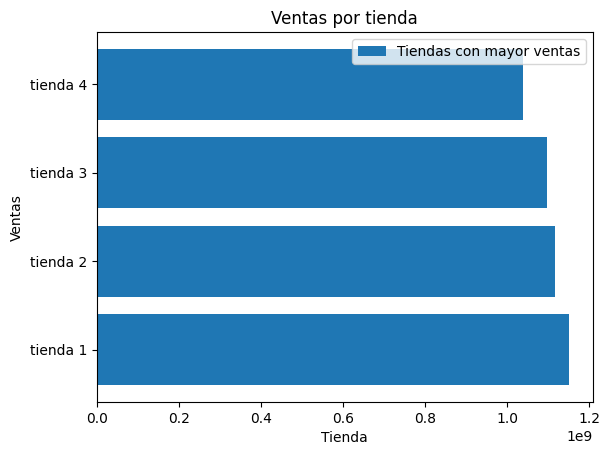


##### la tienda 1 mantiene una proyeccón de ventas aceptables

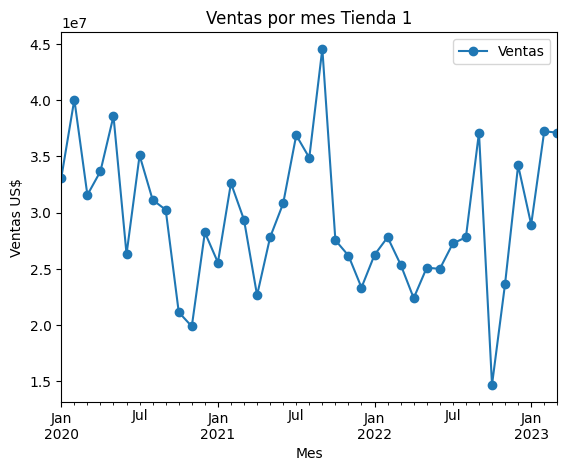

### Analisis de Venta por Categoria

######Las Categorias mas populares de cada tienda son:
• Tienda 1 : Las categorías más vendidas son Muebles (465) y Electrónicos (448).

• Tienda 2 : Las categorías más vendidas son Muebles (442) y Electrónicos (422).

• Tienda 3 : Las categorías más vendidas son Muebles (499) y Electrónicos (451).

• Tienda 4 : Las categorías más vendidas son Muebles (480) y Electrónicos (451).

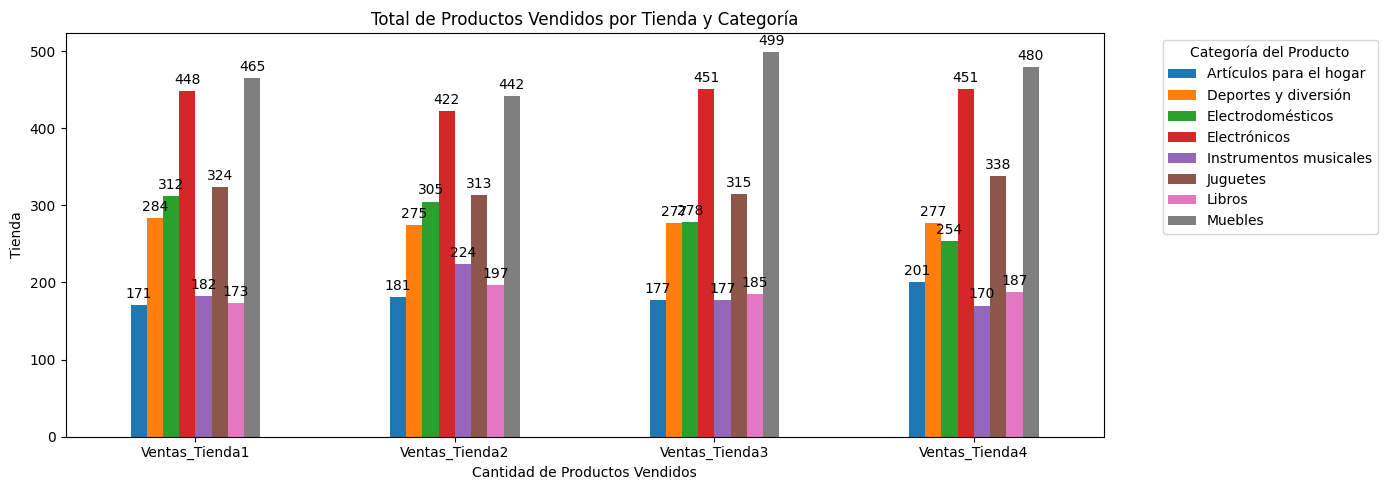

## Calificaciones de tiendas - satisfacción del cliente por tienda


###### a continuación se muestra el promedio de calificacion de los clientes por cada Tienda:

Tienda 1 : 3.98 %\
Tienda 2 : 4.04 %\
Tienda 3 : 4.05 %\
Tienda 4 : 4.00 %

######Se puede apreciar que la **Tienda 3** tiene la mejor calificacion por los clientes con un 4.05% lo que se traduce en una mejor aceptación de los clientes.

## Productos mas Vendidos y menos vendidos por tienda

######A continuacion se muestra los productoas mas y menos vendidos por cada tienda

######
TIENDA 1

*   El producto mas vendido es: *TV LED UHD 4K* con 60 unidades
*   El producto menos vendido es: *Auriculares con micrófono* con 33 unidades

TIENDA 2

*   El producto mas vendido es: *Iniciando en programación* con 65 unidades
*   El producto menos vendido es: *Juego de mesa* con 32 unidades

TIENDA 3

*   El producto mas vendido es: *Kit de bancas* con 57 unidades
*   El producto menos vendido es: *Bloques de construcción* con 35 unidades

TIENDA 4

*   El producto mas vendido es: *Cama box* con 62 unidades
*   El producto menos vendido es: *Guitarra eléctrica* con 33 unidades





##Gasto promedio por Tienda

#####Los gastos promedios que generan las tienadas son:

*   Tienda1 : 26,018.61
*   Tienda2 : 25,216.24
*   Tienda3 : 24,805.68
*   Tienda4 : 23,459.46

Siendo la Tienda 4 el que tiene menos gasto promedio con $ 23,459.46

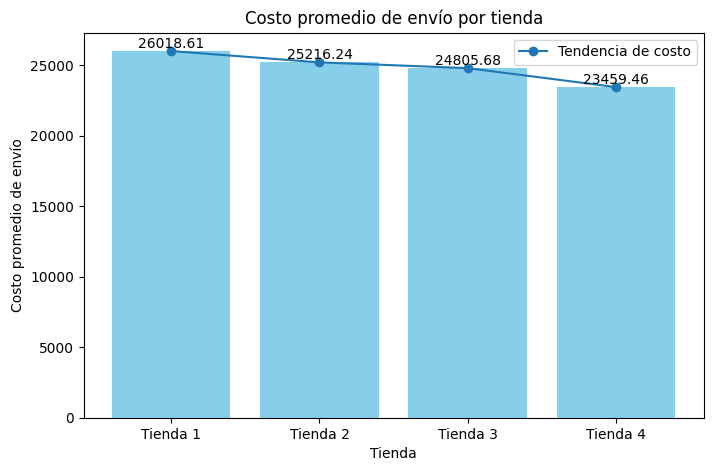

#Resumen y recomendacion para el Sr. Juan

##### Considerando los datos Analizados, se tiene la tienda 4 es quien genera menos ingreso, si bien es cierto tambien genera menos gastos, se aprecia que la tendencia es a la baja de producir ingresos y la aceptación de los clientes no es tan buenas porque esta en penultimo lugar.

Segun los datos es la Tienda 4 que podria ser vendida para iniciar un nuevo emprendimiento.